In [31]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [32]:
def read_csv(csv_file):
    with open(csv_file, 'r') as f:
        lines = f.readlines()
        data = []
        for line in lines[1:]:
            row = line.strip().split(',')
            data.append(row)
    return data

data = read_csv('data/house.csv')
print(data)

X = [[float(row[0])] for row in data]
y = [[float(row[1])] for row in data]
print(f'X: {X}')
print(f'y: {y}')

print(f"Shape of X: ({len(X)}, {len(X[0])})")
print(f"Shape of y: ({len(y)}, {len(y[0])})")

[['30', '448.524'], ['32.4138', '509.248'], ['34.8276', '535.104'], ['37.2414', '551.432'], ['39.6552', '623.418']]
X: [[30.0], [32.4138], [34.8276], [37.2414], [39.6552]]
y: [[448.524], [509.248], [535.104], [551.432], [623.418]]
Shape of X: (5, 1)
Shape of y: (5, 1)


In [33]:
df = pd.read_csv('data/house.csv')
X = df[['Area']].values
y = df[['Price']].values

print(f'Shape of X: {X.shape}')
print(f'Shape of y: {y.shape}')

Shape of X: (5, 1)
Shape of y: (5, 1)


In [42]:
# def loss_function(N, X_bar, y, w):
#     y_hat = X_bar.dot(w)
#     loss = (1 / (2*N)) * np.sum((y_hat - y)**2)
#     return loss

# def gradient(N, X_bar, y, w):
#     y_hat = X_bar.dot(w)
#     gradient = (1/N) * X_bar.T.dot(y_hat - y)
#     return gradient

# def gradient_descent(X, y, lr, threshold=1e-6):
#     N = len(y)
#     X_bar = np.concatenate((np.ones((N, 1)), X), axis=1)
#     w = np.array([[0.0], [1.0]])

#     count = 0
#     converged = False
#     loss = 0.0

#     while not converged:
#         grad = gradient(N, X_bar, y, w)
#         w = w - lr * grad
#         new_loss = loss_function(N, X_bar, y, w)
#         count += 1

#         if count % 100 == 0:
#             print(f"Iteration {count}: Loss={new_loss:.3f}")

#         if abs(new_loss - loss) <= threshold:
#             converged = True
#             print(f"Model converged after {count} iterations")

#         loss = new_loss
    
#     print('Final weights:')
#     print(f'w0 = {w[0][0]:.3f}, w1 = {w[1][0]:.3f}')
#     return w

# def plot_regression_line(X, y, w):
#     plt.scatter(X, y, color='blue', label='Data Points')
#     x_min, x_max = X.min(), X.max()
#     x_values = np.array([x_min, x_max])
#     y_values = w[0][0] + w[1][0] * x_values
#     plt.plot(x_values, y_values, color='red', label='Regression Line')
#     plt.xlabel('Area')
#     plt.ylabel('Price')
#     plt.title('Linear Regression Fit')
#     plt.legend()
#     plt.show()

In [47]:
def loss_function(N, X, y, w):
    total_loss = 0
    for i in range(N):
        y_hat = w[0] + w[1] * X[i][0]
        total_loss += (y_hat - y[i][0]) ** 2
    return total_loss / (2*N)

def gradient(N, X, y, w):
    grad = [0.0, 0.0]
    for i in range(N):
        xi = X[i][0]
        yi = y[i][0]
        y_hat = w[0] + w[1] * xi
        grad[0] += y_hat - yi
        grad[1] += xi * (y_hat - yi)

    grad[0] = grad[0] / N
    grad[1] = grad[1] / N
    return grad

def gradient_descent(X, y, lr, threshold=1e-6):
    N = len(y)
    w = [0.0, 1.0]
    count = 0
    converged = False
    loss = 0.0

    while not converged:
        grad = gradient(N, X, y, w)
        w[0] -= lr*grad[0]
        w[1] -= lr*grad[1]
        new_loss = loss_function(N, X, y, w)
        count += 1
        if count % 100 == 0:
            print(f"Iteration {count}: Loss={new_loss:.3f}")

        if abs(new_loss - loss) < threshold:
            converged = True
            print(f"Model converged after {count} iterations")
        loss = new_loss

    print('Final weights:')
    print(f'w0 = {w[0]:.3f}, w1 = {w[1]:.3f}')
    return w

def plot_regression_line(X, y, w):
    X_flat = [row[0] for row in X]
    y_flat = [row[0] for row in y]
    plt.scatter(X_flat, y_flat, c='blue', label='Data points')

    x_min, x_max = min(X_flat), max(X_flat)
    y_min = w[0] + w[1] * x_min
    y_max = w[0] + w[1] * x_max

    plt.plot([x_min, x_max], [y_min, y_max], c='red', label='Regression Line')
    plt.xlabel('Area')
    plt.ylabel('Price')
    plt.legend()
    plt.show()


Iteration 100: Loss=90.415
Iteration 200: Loss=90.406
Iteration 300: Loss=90.396
Iteration 400: Loss=90.387
Iteration 500: Loss=90.378
Iteration 600: Loss=90.368
Iteration 700: Loss=90.359
Iteration 800: Loss=90.349
Iteration 900: Loss=90.340
Iteration 1000: Loss=90.331
Iteration 1100: Loss=90.321
Iteration 1200: Loss=90.312
Iteration 1300: Loss=90.303
Iteration 1400: Loss=90.293
Iteration 1500: Loss=90.284
Iteration 1600: Loss=90.275
Iteration 1700: Loss=90.266
Iteration 1800: Loss=90.257
Iteration 1900: Loss=90.247
Iteration 2000: Loss=90.238
Iteration 2100: Loss=90.229
Iteration 2200: Loss=90.220
Iteration 2300: Loss=90.211
Iteration 2400: Loss=90.202
Iteration 2500: Loss=90.193
Iteration 2600: Loss=90.184
Iteration 2700: Loss=90.175
Iteration 2800: Loss=90.166
Iteration 2900: Loss=90.157
Iteration 3000: Loss=90.148
Iteration 3100: Loss=90.139
Iteration 3200: Loss=90.130
Iteration 3300: Loss=90.121
Iteration 3400: Loss=90.112
Iteration 3500: Loss=90.103
Iteration 3600: Loss=90.094
I

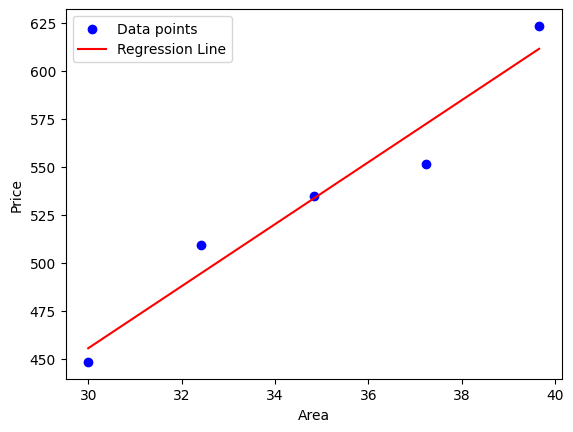

In [50]:
learning_rate = 0.001
threshold = 1e-6
w = gradient_descent(X, y, lr=learning_rate, threshold=threshold)
plot_regression_line(X, y, w)

In [41]:
def predict(X, w):
    y_pred = w[0] + w[1] * X
    return y_pred

new_X = 120
y_pred = predict(new_X, w)
print('Predicted prices:', y_pred)

Predicted prices: 1908.620704066322


In [ ]:
# def predict(X, w):
#     N = len(X)
#     X_bar = np.concatenate((np.ones((N, 1)), X), axis=1)
#     y_hat = X_bar.dot(w)
#     return y_hat

# new_X = np.array([[50], [80], [120]])
# y_pred = predict(new_X, w)
# print('Predicted prices:', y_pred.flatten())

Predicted prices: [ 778.52371718 1262.85099727 1908.62070407]
